<a href="https://colab.research.google.com/github/Ihsan-Fazal/LULC/blob/main/Error_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score,
    jaccard_score
)

# Load saved predictions
y_true = np.load("y_true_hybrid.npy")
y_pred_hybrid = np.load("y_pred_hybrid.npy")
y_pred_deep = np.load("y_pred_deep.npy")

# Class names
target_names = [
    "Tree cover",
    "Shrubland",
    "Grassland",
    "Cropland",
    "Built-up",
    "Water"
]

labels = np.arange(6)

# Check shapes
print("Ground truth:", y_true.shape)
print("Hybrid predictions:", y_pred_hybrid.shape)
print("Deep predictions:", y_pred_deep.shape)

Ground truth: (125,)
Hybrid predictions: (125,)
Deep predictions: (125,)


In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    cohen_kappa_score,
    jaccard_score,
    f1_score,
    precision_score,
    recall_score
)

# 1. Load saved predictions
y_true = np.load("y_true_hybrid.npy")
y_pred_hybrid = np.load("y_pred_hybrid.npy")
y_pred_deep = np.load("y_pred_deep.npy")

# Class names
target_names = [
    "Tree cover",
    "Shrubland",
    "Grassland",
    "Cropland",
    "Built-up",
    "Water"
]

# 2. Function to compute all 6 summary metrics
def get_model_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Cohen's Kappa": cohen_kappa_score(y_true, y_pred),
        "IoU (mean)": jaccard_score(y_true, y_pred, average="macro", zero_division=0),
        "F1 (macro)": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Precision (macro)": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Recall (macro)": recall_score(y_true, y_pred, average="macro", zero_division=0)
    }

# 3. Calculate metrics for both models
hybrid_metrics = get_model_metrics(y_true, y_pred_hybrid)
deep_metrics = get_model_metrics(y_true, y_pred_deep)

# 4. Combine into a comparative DataFrame
df_results = pd.DataFrame([hybrid_metrics, deep_metrics], index=["Hybrid Model", "Deep Learning Model"])

# Display formatted table
print("\n=== MODEL COMPARISON SUMMARY ===")
print(df_results.round(4).to_string())


=== MODEL COMPARISON SUMMARY ===
                     Accuracy  Cohen's Kappa  IoU (mean)  F1 (macro)  Precision (macro)  Recall (macro)
Hybrid Model            0.832         0.7933      0.6891      0.8045             0.7938          0.8467
Deep Learning Model     0.896         0.8712      0.8341      0.9032             0.9061          0.9109


In [18]:
cm_hybrid = confusion_matrix(
    y_true,
    y_pred_hybrid,
    labels=labels
)

cm_deep = confusion_matrix(
    y_true,
    y_pred_deep,
    labels=labels
)

print("Hybrid Confusion Matrix:")
print(cm_hybrid)

print("\nDeep Learning Confusion Matrix:")
print(cm_deep)

Hybrid Confusion Matrix:
[[ 6  0  0  0  0  0]
 [ 0  9  3  0  1  0]
 [ 3  3 16  4  2  1]
 [ 0  0  1 27  0  0]
 [ 2  0  0  0 20  0]
 [ 0  0  0  0  1 26]]

Deep Learning Confusion Matrix:
[[ 6  0  0  0  0  0]
 [ 0 11  1  0  1  0]
 [ 0  2 19  4  4  0]
 [ 0  0  1 27  0  0]
 [ 0  0  0  0 22  0]
 [ 0  0  0  0  0 27]]


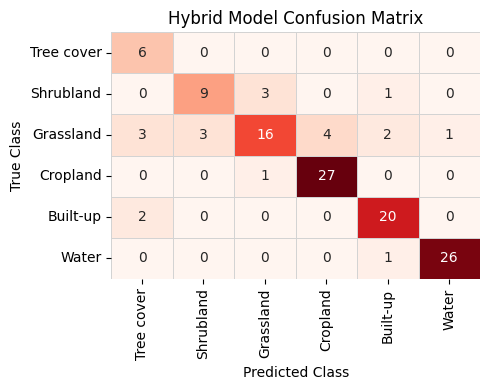

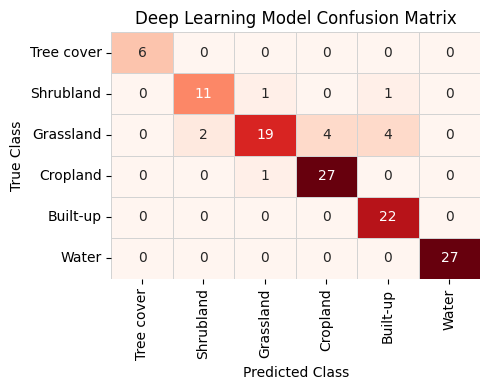

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_hybrid,
    annot=True,
    fmt="d",
    cmap="Reds",
    cbar=False,
    linewidths=0.5,
    linecolor="lightgray",
    xticklabels=target_names,
    yticklabels=target_names
)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Hybrid Model Confusion Matrix")
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_deep,
    annot=True,
    fmt="d",
    cmap="Reds",
    cbar=False,
    linewidths=0.5,
    linecolor="lightgray",
    xticklabels=target_names,
    yticklabels=target_names
)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Deep Learning Model Confusion Matrix")
plt.tight_layout()
plt.show()

In [20]:
report_hybrid = classification_report(
    y_true,
    y_pred_hybrid,
    labels=labels,
    target_names=target_names,
    output_dict=True,
    zero_division=0
)

report_deep = classification_report(
    y_true,
    y_pred_deep,
    labels=labels,
    target_names=target_names,
    output_dict=True,
    zero_division=0
)

f1_hybrid = [
    report_hybrid[class_name]["f1-score"]
    for class_name in target_names
]

f1_deep = [
    report_deep[class_name]["f1-score"]
    for class_name in target_names
]

iou_hybrid = jaccard_score(
    y_true,
    y_pred_hybrid,
    labels=labels,
    average=None,
    zero_division=0
)

iou_deep = jaccard_score(
    y_true,
    y_pred_deep,
    labels=labels,
    average=None,
    zero_division=0
)

In [21]:
error_analysis = pd.DataFrame({
    "Class": target_names,
    "Hybrid F1": f1_hybrid,
    "Deep F1": f1_deep,
    "Hybrid IoU": iou_hybrid,
    "Deep IoU": iou_deep
})

print(error_analysis.round(4))

        Class  Hybrid F1  Deep F1  Hybrid IoU  Deep IoU
0  Tree cover     0.7059   1.0000      0.5455    1.0000
1   Shrubland     0.7200   0.8462      0.5625    0.7333
2   Grassland     0.6531   0.7600      0.4848    0.6129
3    Cropland     0.9153   0.9153      0.8438    0.8438
4    Built-up     0.8696   0.8980      0.7692    0.8148
5       Water     0.9630   1.0000      0.9286    1.0000
